# Flip-chip Penning trap as an anharmonic (transmon-like) magnetron qubit
### Workflow: analytic potential → Laplace-consistent Taylor coefficients → Crimin-2021 diagonalisation with `ladders.py` → Kerr / energy spectrum → geometry + voltage + B optimisation

**Goal.** Maximise the magnetron self-anharmonicity $\alpha_- = E(0,2,0) - 2E(0,1,0) + E(0,0,0)$ of a single electron in the flip-chip trap
(both chips carry the same electrode pattern and voltages, `potFlipBoth` in `20260531_flip_chip_potential_analytic.m`),
over

* electrode geometry (compensation-electrode position and $x$/$z$ extents, radial-electrode width, axial-electrode height),
* the three electrode voltages $(V_c, V_r, V_a)$,
* the magnetic field $B$,
* the chip separation $d \ge 20\,\mu$m,

while keeping the result a *usable* qubit ladder (well-defined levels, spectrally separated modes, insensitive to voltage noise).

**Coordinates** (as in the Mathematica file / Verdú 2011): $y$ = chip normal, $z$ = trap axis ($B\parallel z$), $x$ = in-plane transverse. The radial (cyclotron/magnetron) plane is $x$–$y$.

**Physics summary (see the first answer in this conversation):**
1. The quadratic part of the potential is exactly solvable — Crimin et al. 2021, eqs (19)–(28). Diagonalising it (rotation $U$ + two squeezes $S_\pm$) gives *harmonic* cyclotron/magnetron/axial modes; ellipticity alone gives no anharmonicity.
2. Anharmonicity comes from degree $\ge 3$ terms of the potential. Laplace's equation restricts each degree to harmonic polynomials; the flip-chip mirror symmetries ($x\to-x$, $y\to-y$, $z\to-z$) kill all odd terms, so the first anharmonic terms are the three even quartic knobs ($m=0,2,4$), then sextic.
3. Ellipticity and proximity to the stability edge ($\omega_1 \to 0$) enlarge the magnetron zero-point orbit, which enters the Kerr coefficient to the 4th power — those are the physical levers. Both are limited by voltage-noise sensitivity of $\tilde\omega_-$ and by the requirement that the quasi-bound ladder keeps $\gtrsim 4$ clean levels.

The heavy lifting lives in three modules next to this notebook — `flipchip_potential.py`, `flipchip_quantum.py`, `flipchip_optimize.py` — plus your `ladders.py`.


In [1]:
import time, warnings
import numpy as np
import matplotlib.pyplot as plt

from ladders import Expression, scalar_multiply, squeeze_generator, compare_expr, print_nonzero_terms
import flipchip_potential as fp
import flipchip_quantum as fq
import flipchip_optimize as fo
from flipchip_potential import um, DEFAULT_GEOM, GROUPS
from flipchip_quantum import hbar, m_e, e_ch, q_e

# ---- fabrication parameters (the two knobs you will want to change) --------------------------
MIN_FEATURE = 10*um       # smallest electrode dimension allowed anywhere (comp w/h, radial width,
                          # axial width, axial height); enforced by fp.geometry_ok()
OPT_GAP     = 5*um        # inter-electrode gap used in the optimisation
                          # 20260910 Jaeun: 5um as discussed in the lab meeting.
                          # (TODO: try 3, 5, 10, 20 um and see how the coefficients change)
fp.MIN_FEATURE = MIN_FEATURE
fo.CONSTRAINTS["GAP"] = OPT_GAP
# sensei's GDS design (fp.DEFAULT_GEOM) keeps its own, larger gap:
print(f"min feature {MIN_FEATURE/um:.0f} um   optimisation gap {OPT_GAP/um:.0f} um   "
      f"DEFAULT_GEOM gap {DEFAULT_GEOM['gap']/um:.0f} um   axial width is now a free parameter")

# 20260910 Jaeun: changed the max voltage to 30 V, as discussed in the lab meeting (32 V is as precise as 14 V, the only different was that 32 V was slower.)
fo.CONSTRAINTS["V_MAX"] = 30.0  # V, maximum voltage applied to the electrodes

# ---- orthogonality of the anharmonicity knob (see section 9) --------------------------------
# Theta = fractional pull of w~_- per fractional change of the quartic coefficients when one
# electrode voltage is tuned.  Theta << 1 = an orthogonalised trap.  The penalty in fo.score is
# off while ORTHO_MAX is inf; uncomment to make it bind (start loose at 10, tighten towards 1),
# and set ORTHO_GROUP = "comp" to insist that the compensation electrode is the orthogonal knob.
# fo.CONSTRAINTS["ORTHO_MAX"]   = 10.0
# fo.CONSTRAINTS["ORTHO_GROUP"] = "comp"     # None = any single electrode may be the knob
# fo.CONSTRAINTS["ORTHO_W"]     = 50.0       # penalty weight, quadratic in log10(Theta/ORTHO_MAX)

np.set_printoptions(precision=4, suppress=True, linewidth=140)
MHz = 2*np.pi*1e6
print("modules loaded")

min feature 10 um   optimisation gap 5 um   DEFAULT_GEOM gap 20 um   axial width is now a free parameter
modules loaded


## 1. Electrostatic model — Python port of the Mathematica `FlipChipBoth` potential

`fp.pot0`, `fp.pot_house`, `fp.pot_flip_both` are line-by-line ports of `pot0`, `potHouse`, `potFlipBoth` (House 2008 eq. 22 + alternating image series for the two grounded planes at $y=\pm h$).
The electrode layout is sensei's `20260525_penning_test_v2.gds` parameterised as in the `.m` file (`compCenterX/Y`, `compWidth/Height`, `radialWidth`, `axialHeight`), plus two parameters that used to be hard-coded: the **inter-electrode gap** `gap` (20 µm in the GDS, 5 µm in the optimisation) and the **axial-electrode width** `axial_w`, which the `.m` file fixed to `2*compCenterX - compWidth - 2*gap` = 300 µm and which is now free. Every electrode dimension must be at least `fp.MIN_FEATURE` (10 µm).

Validation: (a) boundary condition (unit potential on the electrode, zero on the grounded plane), (b) exact $y \to -y$ symmetry, (c) convergence of the image series, (d) Laplace equation by finite differences.

potential on the chip plane at (x,z) = (300,300), (0,0), (1000,1000) um [V]: [1. 0. 0.]
phi(y) - phi(-y) = 0.0
phi(0) for nmax = 10, 30, 60: [np.float64(0.12809786109461582), np.float64(0.1277899221741204), np.float64(0.12775675073682444)]
second derivatives: [ 1342098.988   -310371.6572 -1031737.8292]   Laplacian / max|d2| = -7.8223588848123e-06


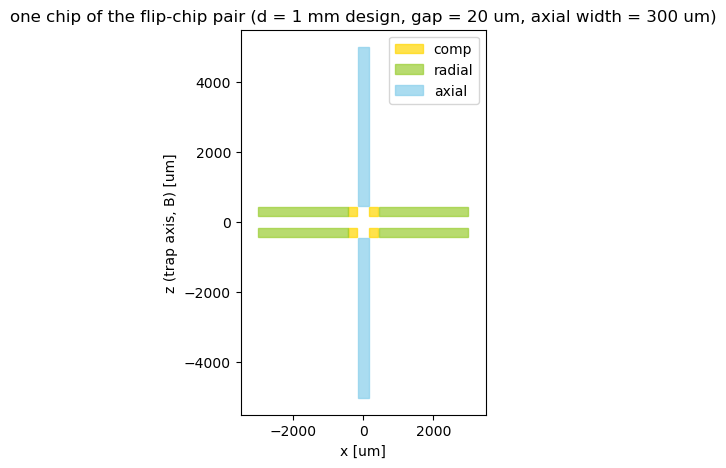

In [2]:
g0 = dict(DEFAULT_GEOM)                       # sensei's design, d = 1 mm, gap = 20 um, axial width 300 um
h0 = g0["sep"]/2
rects = fp.electrode_rects(g0)

# (a) boundary condition on the chip plane (just below y = h): inside comp electrode -> 1 V, outside -> 0 V
xs = np.array([300e-6, 0.0, 1e-3]); zs = np.array([300e-6, 0.0, 1e-3])
print("potential on the chip plane at (x,z) = (300,300), (0,0), (1000,1000) um [V]:",
      fp.group_potential("comp", g0, xs, np.full(3, h0*(1-1e-6)), zs))
# (b) symmetry
print("phi(y) - phi(-y) =", fp.group_potential("comp", g0, 10e-6, 30e-6, 20e-6) - fp.group_potential("comp", g0, 10e-6, -30e-6, 20e-6))
# (c) image series convergence at the centre
print("phi(0) for nmax = 10, 30, 60:", [fp.group_potential("comp", g0, 0., 0., 0., nmax=n) for n in (10, 30, 60)])
# (d) Laplace by finite differences (relative to the largest second derivative)
f = lambda x, y, z: fp.total_potential(g0, dict(comp=1.0, radial=1.0, axial=-1.0), x, y, z)
d = 1e-6; p = (20e-6, 30e-6, 10e-6)
sd = [(f(*(np.array(p)+d*e)) + f(*(np.array(p)-d*e)) - 2*f(*p))/d**2 for e in np.eye(3)]
print("second derivatives:", np.array(sd), "  Laplacian / max|d2| =", sum(sd)/max(abs(s) for s in sd))

# electrode layout
fig, ax = plt.subplots(figsize=(6, 5))
for grp, col in zip(GROUPS, ("gold", "yellowgreen", "skyblue")):
    for (xl, xu, zl, zu) in rects[grp]:
        ax.add_patch(plt.Rectangle((xl/um, zl/um), (xu-xl)/um, (zu-zl)/um, color=col, alpha=0.7, label=grp))
h, l = ax.get_legend_handles_labels(); ax.legend(dict(zip(l, h)).values(), dict(zip(l, h)).keys())
ax.set_xlim(-3500, 3500); ax.set_ylim(-5500, 5500); ax.set_aspect("equal")
ax.set_xlabel("x [um]"); ax.set_ylabel("z (trap axis, B) [um]")
ax.set_title(f"one chip of the flip-chip pair (d = 1 mm design, gap = {g0['gap']/um:.0f} um, axial width = {fp.axial_width(g0)/um:.0f} um)")
plt.show()

## 2. Taylor coefficients $C_{ijk}$ at the trap centre (per volt, per electrode group)

$C_{ijk} = \frac{1}{i!j!k!}\,\partial_x^i\partial_y^j\partial_z^k \Phi\,\big|_0$ (Crimin eq. 6). Instead of symbolic derivatives we fit the unit-voltage potential of each group to an **even polynomial of degree 10** on a small ball around the centre (`fp.fit_taylor`) and validate it with the Laplace equation (`fp.laplace_residual`).

Two things learned while porting:
* The flip-chip symmetry almost completely cancels the *curvature* of the compensation electrodes (individual image terms ≈ 14 000 V/m², sum ≈ 580 V/m²) while their *quartic* term does not cancel — this is why compensation electrodes are the natural Kerr knobs, and also why the fit ball must be small (the quartic overtakes the quadratic only ~30 µm from the centre at $d=1$ mm).
* Sampling on spherical shells makes the fit rank-deficient ($r^2$ is constant on a shell, so $x^6r^2 \equiv x^8$); the ball must be filled.

Uniform scaling obeys the exact Laplace scaling laws $C_2 \propto \lambda^{-2}$, $C_4 \propto \lambda^{-4}$ (the fixed 20 µm gap breaks this only at the 0.3 % level for $C_2$).

In [3]:
t = time.time()
Cg0, resid = fp.taylor_all_groups(g0)
print(f"fit of 3 groups: {time.time()-t:.2f} s, max residual {resid:.1e} V")
quad = [(2,0,0),(0,2,0),(0,0,2)]; quart = [(4,0,0),(0,4,0),(0,0,4),(2,2,0),(0,2,2),(2,0,2)]
print("\nunit-voltage curvatures C200, C020, C002 [V/m^2 per V]   (compare Mathematica diagHess/2)")
for grp in GROUPS:
    print(f"  {grp:7s}", np.array([Cg0[grp][m] for m in quad]), "  Laplace residual:", {k: f"{v:.1e}" for k, v in fp.laplace_residual(Cg0[grp]).items()})
print("\nunit-voltage quartic C400, C040, C004, C220, C022, C202 [V/m^4 per V]   (compare Mathematica anharms/4! etc.)")
for grp in GROUPS:
    print(f"  {grp:7s}", np.array([Cg0[grp][m] for m in quart]))

# uniform scaling check
g_small = {k: v*0.25 for k, v in g0.items()}                 # scales the gap and the axial width too
Cg_small, _ = fp.taylor_all_groups(g_small)
print("\nshrink everything by 4x (gap included):  C002 ratio =", Cg_small['axial'][(0,0,2)]/Cg0['axial'][(0,0,2)],
      "  C004 ratio =", Cg_small['axial'][(0,0,4)]/Cg0['axial'][(0,0,4)], "(expect 16, 256)")

fit of 3 groups: 0.06 s, max residual 5.8e-16 V

unit-voltage curvatures C200, C020, C002 [V/m^2 per V]   (compare Mathematica diagHess/2)
  comp    [  583.5284 -1167.0568   583.5284]   Laplace residual: {2: '1.9e-09', 4: '2.5e-09', 6: '3.6e-07'}
  radial  [ 488686.6456 -398646.9829  -90039.6626]   Laplace residual: {2: '4.7e-12', 4: '3.6e-08', 6: '1.8e-06'}
  axial   [-179667.9013 -251937.8715  431605.7728]   Laplace residual: {2: '2.4e-12', 4: '5.9e-09', 6: '1.2e-06'}

unit-voltage quartic C400, C040, C004, C220, C022, C202 [V/m^4 per V]   (compare Mathematica anharms/4! etc.)
  comp    [-1.2775e+12 -2.0646e+12 -1.2775e+12  6.1939e+12  6.1939e+12  1.4713e+12]
  radial  [-1.2392e+11 -2.1892e+11 -1.4411e+11  5.9618e+11  7.1732e+11  1.4733e+11]
  axial   [ 3.3134e+11 -3.4719e+11  4.2277e+10  1.7438e+11  1.9088e+12 -2.1624e+12]

shrink everything by 4x (gap included):  C002 ratio = 16.0   C004 ratio = 256.0 (expect 16, 256)


## 3. Quadratic problem: canonical quantisation and the Crimin diagonalisation, done with `ladders.py`

We build $H_\varepsilon$ **directly from eq. (10)** — $p^2/2m + \tfrac{\omega_c}{2}(xp_y - yp_x) + \tfrac12 m(\omega_1/2)^2(x^2+y^2) + \tfrac14 m\varepsilon\omega_z^2(x^2-y^2)$ — with $x,y,p_x,p_y$ written in the ladder operators of eqs (14)–(17), and let `ladders.py` normal-order the products. This checks (i) the zero-point normalisation $x = \sqrt{\hbar/m\omega_1}\,(a_x+a_x^\dagger)$, (ii) eq. (19).

One convention detail: eq. (17) taken literally gives $(x^2-y^2) \propto a_+^2 + a_+^{\dagger 2} \boldsymbol{+}\, a_-^2 + a_-^{\dagger 2} + 2(a_+^\dagger a_- + \text{h.c.})$, which is *not* eq. (19). Eq. (19) corresponds to $a_-^{(19)} = -i\,a_-^{(17)}$; we adopt that phase (a harmless relabelling) so that the $\theta$, $\zeta_\pm$ of eqs (21), (26) apply verbatim. `fq.lab_operators` does this.

Then $U$ (eq. 20) and $S(\zeta_+)S(\zeta_-)$ (eq. 23) are applied with `Expression.unitary_transform` (exactly as in your `test_unitary_transform.py`), and the result is compared with eq. (27)–(28) and with the classical normal modes of the $4\times4$ radial equations of motion.

In [4]:
def check_crimin(eps_s, wz_MHz=200., wc_GHz=5.):
    wz = 2*np.pi*wz_MHz*1e6; wc = 2*np.pi*wc_GHz*1e9; B = wc*m_e/e_ch
    C002 = wz**2*m_e/(2*q_e)                                   # eq 9
    C = {(0,0,2): C002, (2,0,0): C002*(eps_s-1)/2, (0,2,0): -C002*(eps_s+1)/2}   # eq 7
    P = fq.quad_params(C, B)
    H = fq.quadratic_hamiltonian_lab(P)                        # eq 10 -> ladders, normal ordered
    # eq 19 written out (note ladders' canonical key order: p+_m is stored as m_p+)
    coef = 0.25*m_e*eps_s*wz**2*P["x_zpf"]**2/hbar
    H19 = scalar_multiply(Expression("p+_p(+)0.5"), P["wp"]) - scalar_multiply(Expression("m+_m(+)0.5"), P["wm"]) \
        + scalar_multiply(Expression("z+_z(+)0.5"), wz) \
        + scalar_multiply(Expression("p+_p+(+)p_p(+)-1m+_m+(+)-1m_m(+)2jm_p+(+)-2jm+_p"), coef)
    dev = max(abs(v) for v in (H - H19).expr_dict.values())/wz
    G = fq.crimin_generators(P)
    Hd = fq.to_diag_frame(H, G)                                # S U H U+ S+
    off = max(abs(v) for k, v in Hd.expr_dict.items() if k not in ("p+_p", "m+_m", "z+_z", ""))/wz
    A = np.array([[0,0,1,0],[0,0,0,1],[-2*q_e*C[(2,0,0)]/m_e,0,0,q_e*B/m_e],[0,-2*q_e*C[(0,2,0)]/m_e,-q_e*B/m_e,0]])
    w_cl = np.sort(np.abs(np.linalg.eigvals(A).imag))[[0, 2]]
    print(f"eps = {eps_s:+.2f}: |H - eq19|/wz = {dev:.1e};  after U,S: off-diagonal/wz = {off:.1e}, "
          f"coef(n+)/w~+ = {Hd.expr_dict['p+_p'].real/P['wt_p']:.10f}, coef(n-)/(-w~-) = {Hd.expr_dict['m+_m'].real/(-P['wt_m']):.10f}; "
          f"theta = {G['theta']:+.4f}, zeta+ = {G['zeta_p']:+.5f}, zeta- = {G['zeta_m']:+.4f}")
    print(f"           classical normal modes / eq 28:  magnetron {w_cl[0]/P['wt_m']:.10f}, cyclotron {w_cl[1]/P['wt_p']:.10f}")

for e in (0.0, 0.3, -0.3, 0.9):
    check_crimin(e)

eps = +0.00: |H - eq19|/wz = 1.5e-15;  after U,S: off-diagonal/wz = 0.0e+00, coef(n+)/w~+ = 1.0000000000, coef(n-)/(-w~-) = 1.0000000001; theta = -0.0000, zeta+ = +0.00000, zeta- = +0.0000
           classical normal modes / eq 28:  magnetron 1.0000000001, cyclotron 1.0000000000
eps = +0.30: |H - eq19|/wz = 1.5e-15;  after U,S: off-diagonal/wz = 1.0e-16, coef(n+)/w~+ = 1.0000000000, coef(n-)/(-w~-) = 1.0000000001; theta = +0.0005, zeta+ = -0.00012, zeta- = -0.1549
           classical normal modes / eq 28:  magnetron 1.0000000001, cyclotron 1.0000000000
eps = -0.30: |H - eq19|/wz = 1.5e-15;  after U,S: off-diagonal/wz = 1.0e-16, coef(n+)/w~+ = 1.0000000000, coef(n-)/(-w~-) = 1.0000000001; theta = -0.0005, zeta+ = +0.00012, zeta- = +0.1549
           classical normal modes / eq 28:  magnetron 1.0000000001, cyclotron 1.0000000000
eps = +0.90: |H - eq19|/wz = 1.5e-15;  after U,S: off-diagonal/wz = 4.4e-16, coef(n+)/w~+ = 1.0000000000, coef(n-)/(-w~-) = 1.0000000003; theta = +0.0014, zeta+

## 4. Anharmonic terms: $x\to\tilde x$, Kerr coefficients, spectrum

Because $U, S_\pm$ are unitary, $\mathcal U\,x^i y^j z^k\,\mathcal U^\dagger = \tilde x^i \tilde y^j \tilde z^k$ with $\tilde x = \mathcal U x\,\mathcal U^\dagger$ **linear** in the new ladders. So we transform only $x, y$ (3 cheap BCH series) and multiply afterwards. `ladders.py` normal-orders
$$\hat V = \frac{q}{\hbar}\sum_{i+j+k \in\{4,6\}} C_{ijk}\,\tilde x^i\tilde y^j\tilde z^k ,$$
and the number-conserving part gives, to first order, $E(n_+,n_-,n_z) = \sum \hbar\tilde\omega n + K_{--}\,n_-(n_--1) + K_{-z} n_- n_z + \dots$, i.e. $\alpha_-^{(1)} = 2K_{--}$.
`fq.kerr_table` reads these off; `fq.alpha_second_order` sums $|\langle f|\hat V|0,n,0\rangle|^2/(E_n-E_f)$ over all 3-mode intermediate states analytically from the term strings; `fq.magnetron_spectrum` diagonalises the exact magnetron operator projected on the cyclotron/axial vacuum (which, for a normal-ordered $\hat V$, is simply the set of pure-$m$ terms).

First the baseline: sensei's 1 mm design with $V_a = -1$ V, $B = 0.5$ T.

In [5]:
volts0 = dict(comp=0.0, radial=0.0, axial=-1.0)
C0 = fp.combine(Cg0, volts0)
P0 = fq.quad_params(C0, 0.5)
print(f"baseline: wz/2pi = {P0['wz']/MHz:.2f} MHz, eps = {P0['eps']:+.4f}, w~+/2pi = {P0['wt_p']/MHz/1e3:.3f} GHz, w~-/2pi = {P0['wt_m']/MHz:.4f} MHz")
t = time.time()
xt, yt, z, G = fq.diag_frame_operators(P0)
print(f"x~ = {xt.expr_dict}")
V4 = fq.anharmonic_operator(C0, xt, yt, z, degrees=(4,))
V46 = fq.anharmonic_operator(C0, xt, yt, z, degrees=(4, 6))
print(f"transform + V4 + V6: {time.time()-t:.3f} s;  V4 has {len(V4.expr_dict)} normal-ordered terms")
kt = fq.kerr_table(V46)
print("number-conserving coefficients [rad/s]:", {k: f"{v:.3e}" for k, v in kt.items()})
a1 = fq.alpha_from_kerr(kt); a2 = fq.alpha_second_order(V46, P0)
E, pur = fq.magnetron_spectrum(V46, P0, dim=30)
print(f"alpha_-/2pi: first order {a1/2/np.pi:.3e} Hz, second order {a2/2/np.pi:.3e} Hz, non-perturbative {(E[2]-2*E[1]+E[0])/2/np.pi:.3e} Hz")

# cross-check the symbolic route against brute-force truncated Fock matrices (fq.FockEngine)
eng = fq.FockEngine(dims=(4, 8, 4), pad=(4, 4, 4))
amps = [fq.ladder_amplitudes(o) for o in (xt, yt, z)]
Hf = eng.hamiltonian(P0, C0, *amps, degrees=(4,))
print(f"Fock-matrix first-order alpha/2pi = {eng.first_order_alpha(Hf)/2/np.pi:.6e} Hz  vs  ladders {fq.alpha_from_kerr(fq.kerr_table(V4))/2/np.pi:.6e} Hz")

baseline: wz/2pi = 62.01 MHz, eps = +0.1674, w~+/2pi = 13.996 GHz, w~-/2pi = 0.1354 MHz
x~ = {'p': np.complex128(2.5655914728445344e-08+0j), 'm': np.complex128(2.791852886476252e-08j), 'p+': np.complex128(2.5655914728445344e-08+0j), 'm+': np.complex128(-2.791852886476252e-08j)}
transform + V4 + V6: 0.052 s;  V4 has 84 normal-ordered terms
number-conserving coefficients [rad/s]: {'shift_p': '-7.378e-02', 'shift_m': '-2.785e-01', 'shift_z': '1.665e+01', 'K_pp': '1.670e-04', 'K_mm': '1.087e-03', 'K_zz': '8.504e+00', 'K_pm': '0.000e+00', 'K_mz': '-5.638e-01', 'K_pz': '-1.507e-01', 'K_mmm': '3.586e-12'}
alpha_-/2pi: first order 3.459e-04 Hz, second order -3.266e-09 Hz, non-perturbative 3.459e-04 Hz
Fock-matrix first-order alpha/2pi = 3.458993e-04 Hz  vs  ladders 3.458993e-04 Hz


A millimetre-scale trap at 1 V gives $\alpha_-/2\pi \sim 10^{-4}$ Hz. To reach MHz we need ~$10^{10}$ — which is where the scaling laws and the two physical levers come in.

## 5. Levers: what actually controls $\alpha_-$

With $K_{--} \propto q\,C_4\,\Lambda_-^4$ and $\Lambda_-$ the magnetron amplitude in $\tilde x$ (which contains $\sqrt{\hbar/m\omega_1}$ and $\cosh\zeta_-,\sinh\zeta_-$):
* **Size**: $C_4/V \propto \lambda^{-4}$ — shrinking the chip is the only way to change the *shape factor*; the gap $d$ enters through $\lambda$.
* **Voltage**: $\alpha \propto V$ at fixed $B$, but so is $\tilde\omega_-\propto\omega_z^2/\omega_c$, so the Kerr *ratio* $\alpha/\tilde\omega_-$ is voltage-independent; larger $V$ only buys absolute MHz.
* **B-field**: $\Lambda^4 \propto \omega_1^{-2}$, so $\alpha$ grows as $B \to B_{\rm crit}=\sqrt2\,\omega_z m/e$ ($\omega_1\to0$); the ratio grows like $1/\omega_1$.
* **Ellipticity**: $\zeta_- \to \pm\infty$ as $|\varepsilon|\to1$ (Crimin fig. 2b), so $\Lambda_-\propto e^{|\zeta_-|}$ explodes while $\tilde\omega_-\to0$.

Both edges make $\tilde\omega_-$ hypersensitive to the voltages ($\partial\tilde\omega_-/\partial\varepsilon \propto 1/(1-|\varepsilon|)$, $\partial\omega_1/\partial\omega_z^2 = -1/\omega_1$), which is what ultimately limits them. Numerical illustration on a 200 µm version of the GDS geometry ($V_a=-14$ V, $V_r$ chosen for $\varepsilon\approx-0.5$):

radial voltage 4.85 V -> eps = -0.502
       mu   alpha/2pi[kHz]  w~-/2pi[MHz]   |alpha|/w~-   jitter[kHz]
[[  0.0032  -3.7277 587.8266   0.       1.8348]
 [  0.0066  -3.4537 580.3982   0.       1.758 ]
 [  0.0137  -3.0028 566.1703   0.       1.6252]
 [  0.0285  -2.3766 540.6242   0.       1.4243]
 [  0.0593  -1.679  498.796    0.       1.1695]
 [  0.1233  -1.0592 437.6346   0.       0.9003]
 [  0.2565  -0.6004 358.7302   0.       0.6546]
 [  0.5337  -0.3025 269.851    0.       0.4503]
 [  1.1103  -0.1315 183.6966   0.       0.2904]
 [  2.3101  -0.0482 112.8057   0.       0.1737]
 [  4.8064  -0.015   63.2833   0.       0.0964]
 [ 10.      -0.0041  33.2237   0.       0.0505]]


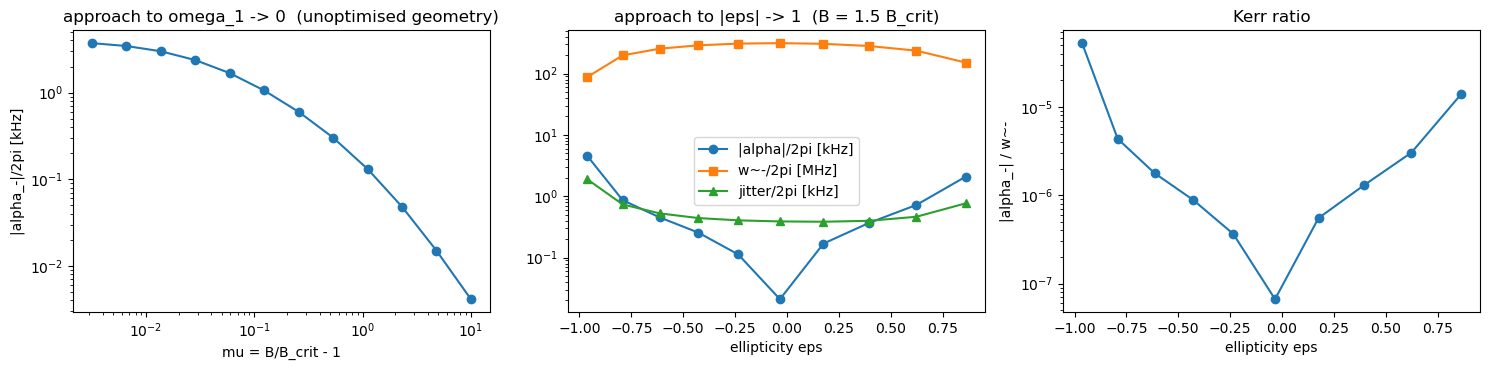

In [6]:
g50 = {k: v*0.2 for k, v in g0.items()}                     # 200 um separation, same shape as the GDS
g50["gap"] = OPT_GAP                                        # but the fabrication gap of the optimisation
assert fp.geometry_ok(g50)
Cg50, _ = fp.taylor_all_groups(g50)
cons_demo = dict(fo.CONSTRAINTS)

def alpha_of(volts, B):
    C = fp.combine(Cg50, volts); P = fq.quad_params(C, B)
    xt, yt, z, G = fq.diag_frame_operators(P, order=60)
    V = fq.anharmonic_operator(C, xt, yt, z, degrees=(4, 6))
    a = fq.alpha_from_kerr(fq.kerr_table(V)) + fq.alpha_second_order(V, P)
    jit, _ = fo.magnetron_freq_jitter(Cg50, volts, B, cons_demo)
    return a, P, G, jit

# (a) B towards the stability edge at fixed voltages (radial voltage chosen to give eps ~ -0.5)
def eps_of(vr):
    C = fp.combine(Cg50, dict(comp=0.0, radial=vr, axial=-14.0)); return (C[(2,0,0)]-C[(0,2,0)])/C[(0,0,2)]
vr0 = min(np.linspace(-14, 14, 561), key=lambda vr: abs(eps_of(vr) + 0.5))
volts = dict(comp=0.0, radial=vr0, axial=-14.0)
print(f"radial voltage {vr0:.2f} V -> eps = {eps_of(vr0):+.3f}")
Bc = fo.b_crit(fp.combine(Cg50, volts))
mus = np.logspace(-2.5, 1, 12)
rows = []
for mu in mus:
    a, P, G, jit = alpha_of(volts, Bc*(1+mu))
    rows.append((mu, a/MHz*1e3, P["wt_m"]/MHz, abs(a)/P["wt_m"], jit/2/np.pi/1e3))
rows = np.array(rows)
print("       mu   alpha/2pi[kHz]  w~-/2pi[MHz]   |alpha|/w~-   jitter[kHz]")
print(rows)

# (b) ellipticity at fixed B/B_crit: vary the radial voltage (which sets C200-C020) at fixed axial curvature
epss, alphas, wms, jits = [], [], [], []
for vr in np.linspace(-10, 10, 15):
    v = dict(comp=0.0, radial=vr, axial=-14.0)
    try:
        C = fp.combine(Cg50, v); a, P, G, jit = alpha_of(v, fo.b_crit(C)*1.5)
    except ValueError:
        continue
    epss.append(P["eps"]); alphas.append(a/MHz*1e3); wms.append(P["wt_m"]/MHz); jits.append(jit/2/np.pi/1e3)

fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
axs[0].loglog(rows[:, 0], np.abs(rows[:, 1]), "o-"); axs[0].set_xlabel("mu = B/B_crit - 1"); axs[0].set_ylabel("|alpha_-|/2pi [kHz]"); axs[0].set_title("approach to omega_1 -> 0  (unoptimised geometry)")
axs[1].semilogy(epss, np.abs(alphas), "o-", label="|alpha|/2pi [kHz]"); axs[1].semilogy(epss, wms, "s-", label="w~-/2pi [MHz]"); axs[1].semilogy(epss, jits, "^-", label="jitter/2pi [kHz]")
axs[1].set_xlabel("ellipticity eps"); axs[1].legend(); axs[1].set_title("approach to |eps| -> 1  (B = 1.5 B_crit)")
axs[2].semilogy(epss, np.abs(alphas)/1e3/np.array(wms), "o-"); axs[2].set_xlabel("ellipticity eps"); axs[2].set_ylabel("|alpha_-| / w~-"); axs[2].set_title("Kerr ratio")
plt.tight_layout(); plt.show()

## 6. Optimisation

`fo.optimize_sep(sep)` maximises $\log_{10}|\alpha_-/2\pi|$ (first + second-order PT) over the 11-vector
(comp centre $x,z$; comp $x,z$ extents; radial width; axial height; **axial width** — all in units of $h = d/2$; $V_c, V_r, V_a$; $\log_{10}\mu$ with $B = (1+\mu)B_{\rm crit}$ so every seed is stable),
with penalties for the constraints in `fo.CONSTRAINTS`:

| constraint | default | why |
|---|---|---|
| $\lvert\alpha_-\rvert \le$ `R_MAX` $\tilde\omega_-$ | 0.10 | Kerr ratio $\alpha/\tilde\omega_-$ (a transmon has ≈0.04). The ladder $E(n)\approx-\tilde\omega_- n+\alpha n^2/2$ folds at $n\approx 1/$`R_MAX`; at 0.10 PT is good to ≈20–30 % and level 2 is a narrow resonance (see §7); at 0.05 PT is good to 10 % |
| $\tilde\omega_- \le$ `S_MAX` $\tilde\omega_+$ | 0.5 | magnetron and cyclotron spectrally distinct |
| $\tilde\omega_- \ge$ `WM_MIN` | 1 MHz | addressability |
| $\ge$ `N_LEVELS` clean levels (Fock purity $\ge$ `PURITY_MIN`) | 4, 0.9 | the anharmonic magnetron potential is unbounded: the ladder is quasi-bound and terminates |
| $\delta\tilde\omega_- \le \lvert\alpha_-\rvert/$`NOISE_RATIO` | 10 | rms $\tilde\omega_-$ jitter from `SIGMA_V`=1e-6 relative + `V_FLOOR`=1 µV per channel (Stahl-class sources) and `SIGMA_B`=1e-8 |
| $\Theta \le$ `ORTHO_MAX` | $\infty$ (off) | orthogonality of the anharmonicity knob: fractional $\tilde\omega_-$ pull per fractional change of the quartics when one electrode is tuned (§9). Set it to make the optimiser keep a usable compensation knob; `ORTHO_GROUP` picks which electrode must be that knob |
| $\lvert V\rvert \le$ `V_MAX`, `B_MIN` $\le B\le$ `B_MAX` | 14 V, 0.05–0.3 T | hardware |
| fabrication | `fo.CONSTRAINTS["GAP"]` = 5 µm electrode gap, every electrode dimension $\ge$ `fp.MIN_FEATURE` = 10 µm, comps must not touch the axis | `fp.geometry_ok` |

The random-geometry sampler uses `fo.shape_bounds(sep)`, i.e. `fo.SHAPE_LO/HI` with the lower bounds lifted to `MIN_FEATURE/h` so that small separations are still sampled inside the fabricable window.

Search: random geometries × random voltages, pre-filtered by the (microsecond) quadratic-level check, `ladders.py` evaluation of survivors (~0.1 s each), then Nelder–Mead on all 10 parameters from the best seeds. Each separation takes 1–2 min on one core.

Edit `SEPS`, `SEEDS`, `fo.CONSTRAINTS` and re-run — everything downstream updates.

In [7]:
import os, pickle
SEPS_UM = [20, 35, 50, 100, 200, 500]
SEPS_UM = [20, 35, 50, 100] # let's save time
SEEDS = (1, 2)
CACHE_FILE = "scan_cache.pkl"           # optimiser results are cached here; delete it to force a fresh scan
cache = fo.TaylorCache()
scan = {}
stored = pickle.load(open(CACHE_FILE, "rb")) if os.path.exists(CACHE_FILE) else {}
stored = {k: x for k, x in stored.items() if len(x) == fo.NDIM}   # drop entries from before axial_w was free
t0 = time.time()
for sep_um in SEPS_UM:
    best = None
    if sep_um in stored:
        r = fo.evaluate(stored[sep_um], sep_um*um, cache)
        if r["ok"]:            # a cached design can become infeasible after a change of MIN_FEATURE / GAP
            best = r; best["x"] = stored[sep_um]; best["score"] = fo.score(stored[sep_um], sep_um*um, cache)
    if best is None:
        for seed in SEEDS:
            r = fo.optimize_sep(sep_um*um, n_geom=30, n_volt=40, n_polish=2, nm_iter=400, seed=seed, cache=cache, verbose=False)
            if r is not None and (best is None or r["score"] > best["score"]):
                best = r
        if best is not None:
            stored[sep_um] = best["x"]; pickle.dump(stored, open(CACHE_FILE, "wb"))
    scan[sep_um] = best
    print(f"--- {sep_um} um  ({time.time()-t0:.0f} s elapsed) ---")
    if best is None:
        print("no feasible design")
    else:
        fo.report(best)

--- 20 um  (88 s elapsed) ---
sep =    20.0 um   B = 0.294 T (= 1.001 x B_crit)   V(comp,rad,ax) = (-10.82, +27.39, +23.88) V
  comp: centre (15.3, 25.0) um, size 11.2 x 24.8 um;  radial width 115.0 um, axial 28.9 (w) x 103.0 (h) um;  gap 5.0 um, min feature 11.2 um
  wz/2pi =   5816.86 MHz   eps = +0.99512   w1/wc = 0.0433   zeta_- = -2.898
  w~+/2pi =   5.821 GHz   w~-/2pi =   286.911 MHz
  alpha_-/2pi =  -16.2044 MHz  (1st order -27.0668, 2nd order +10.8624; non-perturbative -20.0898)
  |alpha|/w~- = 0.056   tau_gate = 5/|alpha| = 0.049 us
  magnetron ladder: transitions/2pi [-311.35 -331.44 -348.7  -363.99 -377.81 -390.54] MHz;  purity [0.999 0.994 0.979 0.947 0.891 0.805 0.69 ]  -> 4 clean levels
  w~- jitter/2pi = 49.06 kHz  (comp 35.11, rad 34.26, ax 0.50, B 0.01 kHz)   |alpha|/jitter = 330.3
  cross-Kerr/2pi: mag-ax +2.4132 MHz, mag-cyc +0.0000 MHz;  axial self-Kerr 2K_zz/2pi = -0.0124 MHz
--- 35 um  (185 s elapsed) ---
sep =    35.0 um   B = 0.220 T (= 1.083 x B_crit)   V(comp

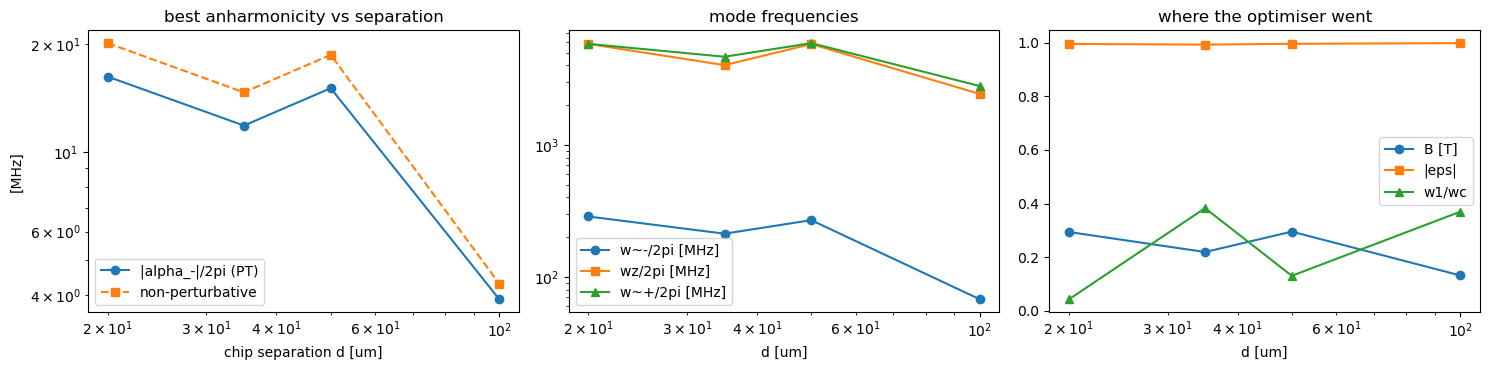

 d[um]  alpha/2pi[MHz]  w~-[MHz]  ratio   B[T]   B/Bc     eps      Vc      Vr      Va jitter[kHz] levels
    20         -16.204    286.91  0.056  0.294  1.001 +0.9951  -10.82  +27.39  +23.88       49.06      4
    35         -11.840    212.53  0.056  0.220  1.083 +0.9925  -12.77  +21.24   +6.67       86.64      4
    50         -15.047    269.03  0.056  0.296  1.009 -0.9955  -18.83  +19.21   -0.89       83.37      4
   100           3.885     67.68  0.057  0.132  1.076 +0.9980  -16.82   +7.86  -22.11       30.12      4


In [8]:
ok = [s for s in SEPS_UM if scan[s] is not None]
fig, axs = plt.subplots(1, 3, figsize=(15, 3.8))
axs[0].loglog(ok, [abs(scan[s]["alpha"])/MHz for s in ok], "o-", label="|alpha_-|/2pi (PT)")
axs[0].loglog(ok, [abs(scan[s]["alpha_np"])/MHz for s in ok], "s--", label="non-perturbative")
axs[0].set_xlabel("chip separation d [um]"); axs[0].set_ylabel("[MHz]"); axs[0].legend(); axs[0].set_title("best anharmonicity vs separation")
axs[1].loglog(ok, [scan[s]["P"]["wt_m"]/MHz for s in ok], "o-", label="w~-/2pi [MHz]")
axs[1].loglog(ok, [scan[s]["P"]["wz"]/MHz for s in ok], "s-", label="wz/2pi [MHz]")
axs[1].loglog(ok, [scan[s]["P"]["wt_p"]/MHz for s in ok], "^-", label="w~+/2pi [MHz]")
axs[1].set_xlabel("d [um]"); axs[1].legend(); axs[1].set_title("mode frequencies")
axs[2].semilogx(ok, [scan[s]["B"] for s in ok], "o-", label="B [T]")
axs[2].semilogx(ok, [abs(scan[s]["P"]["eps"]) for s in ok], "s-", label="|eps|")
axs[2].semilogx(ok, [scan[s]["P"]["w1"]/scan[s]["P"]["wc"] for s in ok], "^-", label="w1/wc")
axs[2].set_xlabel("d [um]"); axs[2].legend(); axs[2].set_title("where the optimiser went")
plt.tight_layout(); plt.show()

print(f"{'d[um]':>6} {'alpha/2pi[MHz]':>15} {'w~-[MHz]':>9} {'ratio':>6} {'B[T]':>6} {'B/Bc':>6} {'eps':>7} {'Vc':>7} {'Vr':>7} {'Va':>7} {'jitter[kHz]':>11} {'levels':>6}")
for s in ok:
    r = scan[s]; P = r["P"]; v = r["volts"]
    print(f"{s:6d} {r['alpha']/MHz:15.3f} {P['wt_m']/MHz:9.2f} {r['ratio']:6.3f} {r['B']:6.3f} {r['B']/fo.b_crit(r['C']):6.3f} {P['eps']:+7.4f} {v['comp']:+7.2f} {v['radial']:+7.2f} {v['axial']:+7.2f} {r['jitter']/2/np.pi/1e3:11.2f} {r['n_bound']:6d}")

## 7. Refine the best design and verify it non-perturbatively

We take the best separation, polish it further, and then check the spectrum without perturbation theory:
1. **1-mode projected ladder** (`fq.magnetron_spectrum`) at several basis sizes — the levels below the fold $n \lesssim \tilde\omega_-/|\alpha|$ must be basis-independent;
2. **full 3-mode truncated-Fock diagonalisation** (`fq.FockEngine`, including degree-8 terms) — checks that non-secular couplings to cyclotron/axial do not spoil the ladder;
3. **PT vs exact as a function of the Kerr ratio** (varying only $B$) — shows where first+second-order PT stops being trustworthy, i.e. justifies `R_MAX`.

In [9]:
best_sep = max(ok, key=lambda s: abs(scan[s]["alpha"]))
best_sep = 35. # I want to use the 35um design for the next steps, as it gives some margin on the voltages, B-Bc is also not too small, and the magnetron frequency is not too small (which would make the trap more sensitive to noise). I will use this design for the next steps.
best = fo.optimize_sep(best_sep*um, n_geom=0, n_polish=1, nm_iter=600, x0=scan[best_sep]["x"], cache=cache, verbose=False)
best = best if best is not None and best["score"] > scan[best_sep]["score"] else scan[best_sep]
print("refined best design:")
fo.report(best)
P, C, V = best["P"], best["C"], best["V"]

print("\n(1) 1-mode projected ladder vs basis size  [transition frequencies / 2pi, MHz  |  purities]")
for dim in (10, 16, 24, 40):
    E, pur = fq.magnetron_spectrum(V, P, dim=dim, nmax=5)
    print(f"  dim {dim:3d}: {np.round(np.diff(E)/MHz, 3)}   {np.round(pur, 3)}")

print("\n(2) 3-mode truncated Fock (cyclotron x magnetron x axial), degrees 4+6+8")
xt, yt, z, G = fq.diag_frame_operators(P, order=60)
amps = [fq.ladder_amplitudes(o) for o in (xt, yt, z)]
print(f"  magnetron amplitude |c_m| in x~, y~: {abs(amps[0]['m'][0])*1e9:.1f}, {abs(amps[1]['m'][0])*1e9:.1f} nm;  "
      f"cyclotron: {abs(amps[0]['p'][0])*1e9:.1f}, {abs(amps[1]['p'][0])*1e9:.1f} nm;  axial z_zpf {P['z_zpf']*1e9:.1f} nm;  fit radius {0.08*best['g']['sep']/2*1e6:.1f} um")
t = time.time()
eng3 = fq.FockEngine(dims=(2, 16, 4), pad=(2, 6, 2))
H3 = eng3.hamiltonian(P, C, *amps, degrees=(4, 6, 8))
E3, pur3 = eng3.magnetron_ladder(H3, nmax=5)
print(f"  ({time.time()-t:.1f} s)  transitions/2pi: {np.round(np.diff(E3)/MHz, 3)} MHz   purities {np.round(pur3, 3)}")
print(f"  alpha_- non-perturbative (3-mode) = {(E3[2]-2*E3[1]+E3[0])/MHz:+.3f} MHz;  PT (1st+2nd) = {best['alpha']/MHz:+.3f} MHz")

refined best design:
sep =    35.0 um   B = 0.206 T (= 1.000 x B_crit)   V(comp,rad,ax) = (-12.78, +21.23, +5.01) V
  comp: centre (21.0, 31.0) um, size 12.6 x 45.9 um;  radial width 98.2 um, axial 15.5 (w) x 99.4 (h) um;  gap 5.0 um, min feature 12.6 um
  wz/2pi =   4082.28 MHz   eps = +0.99187   w1/wc = 0.0199   zeta_- = -3.158
  w~+/2pi =   4.076 GHz   w~-/2pi =   260.145 MHz
  alpha_-/2pi =  -14.4708 MHz  (1st order -23.9616, 2nd order +9.4908; non-perturbative -17.7503)
  |alpha|/w~- = 0.056   tau_gate = 5/|alpha| = 0.055 us
  magnetron ladder: transitions/2pi [-282.08 -299.83 -315.08 -328.57 -340.75 -351.97] MHz;  purity [0.999 0.994 0.979 0.948 0.892 0.807 0.693]  -> 4 clean levels
  w~- jitter/2pi = 95.41 kHz  (comp 68.19, rad 66.72, ax 0.10, B 0.01 kHz)   |alpha|/jitter = 151.7
  cross-Kerr/2pi: mag-ax +1.3250 MHz, mag-cyc +0.0000 MHz;  axial self-Kerr 2K_zz/2pi = -0.0455 MHz

(1) 1-mode projected ladder vs basis size  [transition frequencies / 2pi, MHz  |  purities]
  dim  10

(3) PT vs exact ladder as B is moved towards the stability edge (all else fixed)
 B/Bcrit  w~-/2pi[MHz]   ratio   alpha1   alpha2   PT sum    exact               purity(0..3)
   1.000        260.22  0.0556  -23.976    9.499  -14.477  -17.760   [0.999 0.994 0.979 0.948]
   1.000        260.21  0.0556  -23.973    9.498  -14.476  -17.758   [0.999 0.994 0.979 0.948]
   1.000        260.18  0.0556  -23.969    9.495  -14.474  -17.755   [0.999 0.994 0.979 0.948]
   1.000        260.15  0.0556  -23.962    9.491  -14.471  -17.750   [0.999 0.994 0.979 0.948]
   1.000        260.08  0.0556  -23.950    9.484  -14.466  -17.743   [0.999 0.994 0.979 0.948]
   1.000        259.99  0.0556  -23.932    9.473  -14.459  -17.731   [0.999 0.994 0.979 0.948]
   1.001        259.84  0.0556  -23.904    9.457  -14.447  -17.713   [0.999 0.994 0.979 0.948]
   1.001        259.60  0.0556  -23.858    9.430  -14.429  -17.684   [0.999 0.994 0.979 0.948]
   1.002        259.22  0.0556  -23.787    9.388  -14.399  -17.63

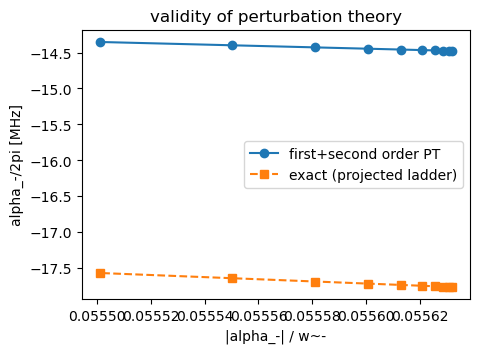

In [10]:
print("(3) PT vs exact ladder as B is moved towards the stability edge (all else fixed)")
print(f"{'B/Bcrit':>8} {'w~-/2pi[MHz]':>13} {'ratio':>7} {'alpha1':>8} {'alpha2':>8} {'PT sum':>8} {'exact':>8} {'purity(0..3)':>26}")
cons_chk = dict(fo.CONSTRAINTS); cons_chk["FOCK_DIM"] = 24
ratios, a_pt, a_np = [], [], []
for logmu in np.linspace(best["x"][fo.ILOGMU] - 0.6, best["x"][fo.ILOGMU] + 1.2, 10):
    x = best["x"].copy(); x[fo.ILOGMU] = logmu
    r = fo.evaluate(x, best["g"]["sep"], cache, cons_chk)
    if not r["ok"]:
        continue
    print(f"{r['B']/fo.b_crit(r['C']):8.3f} {r['P']['wt_m']/MHz:13.2f} {r['ratio']:7.4f} {r['alpha1']/MHz:8.3f} {r['alpha2']/MHz:8.3f} {r['alpha']/MHz:8.3f} {r['alpha_np']/MHz:8.3f}   {np.round(r['purity'][:4], 3)}")
    ratios.append(r["ratio"]); a_pt.append(r["alpha"]/MHz); a_np.append(r["alpha_np"]/MHz)
plt.figure(figsize=(5, 3.5)); plt.plot(ratios, a_pt, "o-", label="first+second order PT"); plt.plot(ratios, a_np, "s--", label="exact (projected ladder)")
plt.xlabel("|alpha_-| / w~-"); plt.ylabel("alpha_-/2pi [MHz]"); plt.legend(); plt.title("validity of perturbation theory"); plt.show()

## 8. The recommended design

sep =    35.0 um   B = 0.206 T (= 1.000 x B_crit)   V(comp,rad,ax) = (-12.78, +21.23, +5.01) V
  comp: centre (21.0, 31.0) um, size 12.6 x 45.9 um;  radial width 98.2 um, axial 15.5 (w) x 99.4 (h) um;  gap 5.0 um, min feature 12.6 um
  wz/2pi =   4082.28 MHz   eps = +0.99187   w1/wc = 0.0199   zeta_- = -3.158
  w~+/2pi =   4.076 GHz   w~-/2pi =   260.145 MHz
  alpha_-/2pi =  -14.4708 MHz  (1st order -23.9616, 2nd order +9.4908; non-perturbative -17.7503)
  |alpha|/w~- = 0.056   tau_gate = 5/|alpha| = 0.055 us
  magnetron ladder: transitions/2pi [-282.08 -299.83 -315.08 -328.57 -340.75 -351.97] MHz;  purity [0.999 0.994 0.979 0.948 0.892 0.807 0.693]  -> 4 clean levels
  w~- jitter/2pi = 95.41 kHz  (comp 68.19, rad 66.72, ax 0.10, B 0.01 kHz)   |alpha|/jitter = 151.7
  cross-Kerr/2pi: mag-ax +1.3250 MHz, mag-cyc +0.0000 MHz;  axial self-Kerr 2K_zz/2pi = -0.0455 MHz
noise budget of w~- (jitter/2pi, kHz): comp 68.19, radial 66.72, axial 0.10, B 0.01  ->  total 95.41 kHz,  |alpha|/jitter =

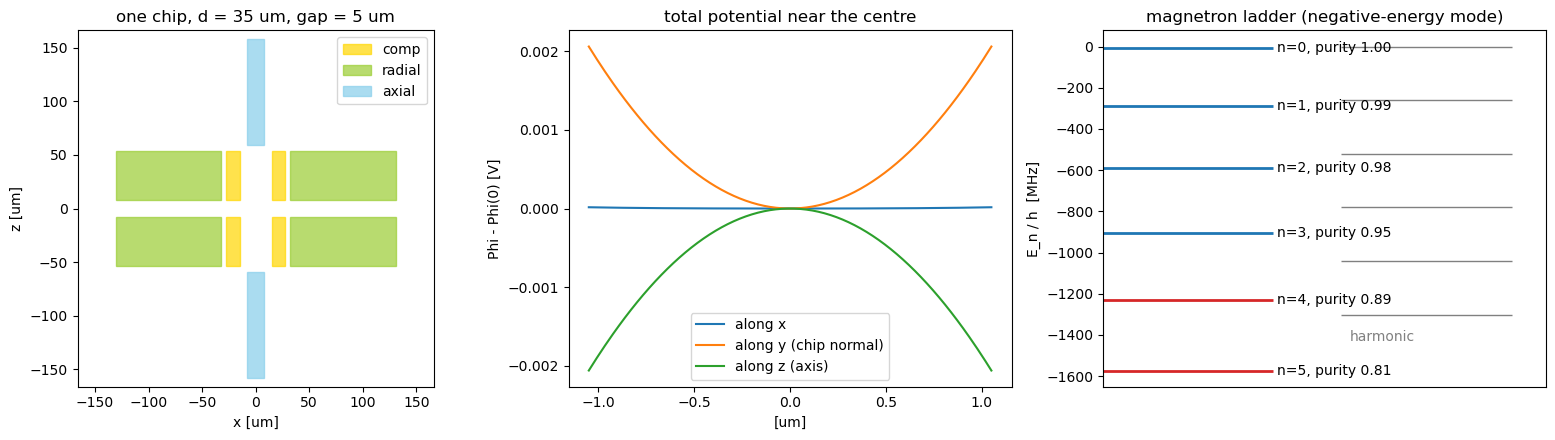

In [11]:
r = best; g = r["g"]; v = r["volts"]; P = r["P"]; k = r["kerr"]
print("=" * 100)
fo.report(r)
print("=" * 100)
print("noise budget of w~- (jitter/2pi, kHz): " + ", ".join(f"{k} {v/2/np.pi/1e3:.2f}" for k, v in r['jitter_contrib'].items())
      + f"  ->  total {r['jitter']/2/np.pi/1e3:.2f} kHz,  |alpha|/jitter = {r['noise_ratio']:.0f}")
print(f"gate time 5/|alpha| = {5/abs(r['alpha'])*1e6:.3f} us;  Yurke-Stoler cat formation time pi/|alpha| = {np.pi/abs(r['alpha'])*1e6:.3f} us")
print(f"first-order Kerr table (MHz): mag self {2*k['K_mm']/MHz:+.3f}, ax self {2*k['K_zz']/MHz:+.4f}, cyc self {2*k['K_pp']/MHz:+.4f}, "
      f"mag-ax cross {k['K_mz']/MHz:+.4f}, mag-cyc cross {k['K_pm']/MHz:+.4f}, cyc-ax cross {k['K_pz']/MHz:+.4f}")

# layout + potential
rects = fp.electrode_rects(g); h = g["sep"]/2
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))
for grp, col in zip(GROUPS, ("gold", "yellowgreen", "skyblue")):
    for (xl, xu, zl, zu) in rects[grp]:
        axs[0].add_patch(plt.Rectangle((xl/um, zl/um), (xu-xl)/um, (zu-zl)/um, color=col, alpha=0.7, label=grp))
hh, ll = axs[0].get_legend_handles_labels(); axs[0].legend(dict(zip(ll, hh)).values(), dict(zip(ll, hh)).keys(), loc="upper right")
gap = fp.gap_of(g)
span = max(g["comp_cx"] + g["comp_w"]/2 + gap + g["radial_w"], g["comp_cz"] + g["comp_h"]/2 + gap + g["axial_h"], fp.axial_width(g)/2) / um * 1.05
axs[0].set_xlim(-span, span); axs[0].set_ylim(-span, span); axs[0].set_aspect("equal")
axs[0].set_xlabel("x [um]"); axs[0].set_ylabel("z [um]"); axs[0].set_title(f"one chip, d = {g['sep']/um:.0f} um, gap = {gap/um:.0f} um")

s = np.linspace(-1, 1, 201) * 0.06 * h
phi = lambda x, y, z: fp.total_potential(g, v, x, y, z)
axs[1].plot(s/um, phi(s, 0*s, 0*s) - phi(0., 0., 0.), label="along x")
axs[1].plot(s/um, phi(0*s, s, 0*s) - phi(0., 0., 0.), label="along y (chip normal)")
axs[1].plot(s/um, phi(0*s, 0*s, s) - phi(0., 0., 0.), label="along z (axis)")
axs[1].set_xlabel("[um]"); axs[1].set_ylabel("Phi - Phi(0) [V]"); axs[1].legend(); axs[1].set_title("total potential near the centre")

E, pur = fq.magnetron_spectrum(r["V"], P, dim=16, nmax=5)
for n, (en, pu) in enumerate(zip(E, pur)):
    axs[2].hlines(en/MHz, 0, 1, color="C0" if pu > 0.9 else "C3", lw=2)
    axs[2].text(1.02, en/MHz, f"n={n}, purity {pu:.2f}", va="center")
axs[2].hlines(-P["wt_m"]*np.arange(6)/MHz, 1.4, 2.4, color="gray", lw=1)
axs[2].text(1.45, -P["wt_m"]*5.5/MHz, "harmonic", color="gray")
axs[2].set_xlim(0, 2.6); axs[2].set_xticks([]); axs[2].set_ylabel("E_n / h  [MHz]"); axs[2].set_title("magnetron ladder (negative-energy mode)")
plt.tight_layout(); plt.show()

## 9. Orthogonality of the tuning knobs

In the precision-measurement language a trap is *orthogonalised* when the compensation electrode changes the anharmonicity without moving the axial frequency: $\partial C_2/\partial V_{\rm comp} \simeq 0$. In the original GDS geometry this came almost for free — the flip-chip mirror symmetry very nearly cancels the *curvature* of the compensation pads (§2: individual image terms $\approx 14\,000$ V/m$^2$, sum $\approx 580$ V/m$^2$) while leaving their quartic term intact. The optimiser is free to move and reshape those pads and nothing in `fo.score` rewards that cancellation, so it is worth measuring what survives.

Three measures, from the most geometric to the most operational:

1. **Per-group shape ratio** $|c_4|/|c_2|$, with $c_2 = |C_2|\,h^2$ and $c_4 = |C_4|\,h^4$ per volt ($h = d/2$, so both are dimensionless). Pure geometry — no voltages, no $B$ — hence the fair comparison between designs of different size. A large ratio marks a "mostly quartic", i.e. orthogonal, electrode.
2. **The harmonic-null direction.** Laplace forces $C_{200}+C_{020}+C_{002}=0$, so the $3\times3$ matrix $\partial C_2/\partial V$ has rank 2: with three electrode groups there is *always* a voltage direction $\hat n$ along which every curvature — hence $\omega_z$, $\varepsilon$, $\omega_1$ and both $\tilde\omega_\pm$ — is exactly unchanged while the quartics move. Orthogonality is therefore never lost outright; what the geometry decides is (a) how much of $\hat n$ sits on the small compensation pads rather than on the high-voltage axial electrode, and (b) how much $\alpha_-$ it buys per volt.
3. **Sensitivities and tuning authority at the operating point.** $\Lambda = |{\rm d}\tilde\omega_-/{\rm d}\alpha_-|$ is the within-design figure of merit — Hz of qubit-frequency pull per Hz of anharmonicity gained, zero for a perfect knob. The fractional version $|{\rm d}\ln\tilde\omega_-/{\rm d}\ln|\alpha_-||$ is the classic one, but it is inflated wherever $\alpha_-$ passes through zero (the GDS baseline at $V_c=0$ nearly does), so read it next to $\Lambda$ and the range table. The figure plots the frequency pull against the anharmonicity actually reached, for each knob, over the range where the trap stays stable and within `V_MAX`: **a flat line is an orthogonal knob**.

Two things make the optimised point harsher than the GDS baseline whatever the electrode shapes are: it sits at $B\approx B_{\rm crit}$ and $|\varepsilon|\to1$, where $\tilde\omega_-$ is by construction hypersensitive to *any* curvature change (§5) — the same sensitivity the noise budget already charges for. So the `harmonic-null combo` row, not the `comp only` row, is the answer to "can I still tune $\alpha_-$ at fixed frequency", and its `usable ±t` column is the answer to "by how much".

**The penalty in `fo.score`.** `fo.orthogonality(Cg, volts, B)` returns, for each electrode group,

$$\Theta_g = \frac{|{\rm d}\tilde\omega_-|/\tilde\omega_-}{|{\rm d}\vec C_4|/|\vec C_4|}\qquad\text{for a small step on } V_g,$$

the same idea as $\Lambda$ but normalised so that it is dimensionless and comparable across designs, and cheap enough for the inner loop (120 µs — the frequency response needs only `quad_params`, the quartic response is exact linear algebra, and $\Theta$ is independent of the step size). It is deliberately *stricter* than $|{\rm d}\ln\tilde\omega_-/{\rm d}\ln|\alpha_-||$: $\alpha_-$ also changes because a curvature change reshapes the modes, and crediting that would credit exactly the non-orthogonal part of the tuning, so $\Theta$ counts only the anharmonicity coming from the anharmonic coefficients themselves. `|dC4|` is the length of the change vector, not the change of the length, so it cannot vanish spuriously.

`fo.score` subtracts `ORTHO_W * max(0, log10(Theta/ORTHO_MAX))**2` (quadratic in the *logarithm*, since $\Theta$ spans decades), where $\Theta$ is that of `ORTHO_GROUP`, or of the best single electrode when it is `None`. The penalty is **off by default** (`ORTHO_MAX = inf`) so it does not silently change earlier results — $\Theta$ is always computed and printed by `fo.report`. Uncomment the switch in the first cell to turn it on, then re-run §6. For scale: the GDS compensation electrode has $\Theta \approx 5\times10^{-4}$, an unconstrained optimum can land at $\Theta \sim 10$–$30$, and with `ORTHO_MAX = 1` a $\Theta = 17$ design loses $\approx 75$ points of score against an objective worth $\approx 6$ — so expect a real trade against $\alpha_-$, and start loose (`ORTHO_MAX = 10`) to see the exchange rate.

In [ ]:
# ---------------------------------------------------------------------------
# Orthogonality of the tuning knobs: how much does the frequency move when we
# tune the anharmonicity?  (the "orthogonalised trap" of the precision-
# measurement community: an electrode with dC2/dV = 0)
# ---------------------------------------------------------------------------
QUAD  = [(2,0,0),(0,2,0),(0,0,2)]
QUART = [(4,0,0),(0,4,0),(0,0,4),(2,2,0),(2,0,2),(0,2,2)]

def shape_table(Cg, gg, label):
    """Geometry only, no voltages: curvature vs quartic strength of each electrode group
    per volt, made dimensionless with h = d/2.  |c4|/|c2| >> 1 marks a 'mostly quartic'
    (orthogonal) electrode -- this is the number that does not depend on the operating
    point, so it is the fair comparison between designs of different size."""
    hh = gg["sep"]/2
    print(f"{label}   (h = d/2 = {hh/um:.1f} um)")
    print(f"  {'group':8s} {'|c2| = |C2| h^2':>16} {'|c4| = |C4| h^4':>16} {'|c4|/|c2|':>12}")
    for grp in GROUPS:
        c2 = np.linalg.norm([Cg[grp][m] for m in QUAD])*hh**2
        c4 = np.linalg.norm([Cg[grp][m] for m in QUART])*hh**4
        print(f"  {grp:8s} {c2:16.4g} {c4:16.4g} {c4/c2:12.4g}")

def harmonic_null(Cg):
    """The voltage direction that leaves C200, C020 and C002 -- hence wz, eps, w1 and both
    dressed radial frequencies -- exactly unchanged.  Laplace (C200+C020+C002 = 0) makes the
    3x3 matrix dC2/dV rank 2, so with three electrode groups such a direction always exists:
    it is the trap's built-in compensation knob, whatever the electrode shapes are.
    Returns (direction scaled to max |component| = 1, singular values, relative residual)."""
    M = np.array([[Cg[grp][m] for grp in GROUPS] for m in QUAD])
    _, sv, vt = np.linalg.svd(M)
    n = vt[-1]/np.abs(vt[-1]).max()
    return n, sv, np.linalg.norm(M @ n)/np.linalg.norm(M)

def obs(Cg, vd, B):
    """(quadratic parameters, alpha_-) at a voltage set; raises ValueError if unstable."""
    C = fp.combine(Cg, vd); Pq = fq.quad_params(C, B)
    xo, yo, zo, _ = fq.diag_frame_operators(Pq, order=60)
    Vop = fq.anharmonic_operator(C, xo, yo, zo, degrees=(4, 6))
    return Pq, fq.alpha_from_kerr(fq.kerr_table(Vop)) + fq.alpha_second_order(Vop, Pq)

def vshift(vd, u, t):
    return {grp: vd[grp] + t*ui for grp, ui in zip(GROUPS, u)}

def sens_table(Cg, vd, B, dirs, dv=1e-3):
    """Response to a 1 V move along each direction.
    Lambda = |dw~_-/dalpha_-| is the within-design figure of merit: how many Hz the qubit
    frequency moves per Hz of anharmonicity gained (orthogonal knob -> 0).  The last column
    is the classic fractional version; it is inflated when alpha_- happens to pass through
    zero near the operating point, so read it together with Lambda and the range table."""
    P0, a0 = obs(Cg, vd, B)
    print(f"  operating point: alpha_-/2pi = {a0/MHz:+.4g} MHz, w~_-/2pi = {P0['wt_m']/MHz:.4g} MHz, wz/2pi = {P0['wz']/MHz:.4g} MHz")
    print(f"  {'direction':22} {'dalpha/dV [MHz/V]':>18} {'dw~_-/dV [MHz/V]':>17} {'dln wz/dV [1/V]':>16}"
          f" {'Lambda=|dw~_-/dalpha|':>22} {'|dln w~_-/dln|a||':>18}")
    for name, u in dirs.items():
        try:
            Pp, ap = obs(Cg, vshift(vd, u,  dv), B)
            Pm, am = obs(Cg, vshift(vd, u, -dv), B)
        except ValueError:
            print(f"  {name:22} unstable at +-{dv} V"); continue
        da   = (ap - am)/(2*dv)                              # rad/s per V
        dabs = (abs(ap) - abs(am))/(2*dv)
        dm   = (Pp["wt_m"] - Pm["wt_m"])/(2*dv)
        dlnz = (Pp["wz"] - Pm["wz"])/(Pp["wz"] + Pm["wz"])/dv
        lam  = abs(dm/da) if da != 0 else np.inf
        lnr  = abs((dm/P0["wt_m"])/(dabs/abs(a0))) if dabs != 0 else np.inf
        print(f"  {name:22} {da/MHz:18.4g} {dm/MHz:17.6g} {dlnz:16.3e} {lam:22.4g} {lnr:18.3e}")

def volt_limit(vd, u, vmax):
    lim = [(vmax - abs(vd[grp]))/abs(ui) for grp, ui in zip(GROUPS, u) if abs(ui) > 1e-12]
    return max(0.0, min(lim))

def usable_range(Cg, vd, B, u, vmax):
    """Voltage limit, shrunk until both end points are still a stable trap: near the
    stability edge a non-orthogonal knob runs out of stability long before it runs out
    of voltage, which is itself part of the answer."""
    t = volt_limit(vd, u, vmax)
    for _ in range(24):
        try:
            obs(Cg, vshift(vd, u, t), B); obs(Cg, vshift(vd, u, -t), B); return t
        except ValueError:
            t /= 2
    return 0.0

def scan_dir(Cg, vd, B, u, tmax, npts=13):
    ts, A, W = [], [], []
    for t in np.linspace(-tmax, tmax, npts):
        try:
            Pq, a = obs(Cg, vshift(vd, u, t), B)
        except ValueError:
            continue
        ts.append(t); A.append(a); W.append(Pq["wt_m"])
    return np.array(ts), np.array(A), np.array(W)

DIRS = lambda n_: {"comp only": (1., 0., 0.), "radial only": (0., 1., 0.),
                   "axial only": (0., 0., 1.), "harmonic-null combo": tuple(n_)}

# --- the designs to compare: the optimiser's answer vs sensei's GDS --------
designs = [(f"optimised design (d = {best['g']['sep']/um:.0f} um)", best["Cg"], best["g"], best["volts"], best["B"])]
if "Cg0" in globals():
    designs.append(("original GDS design (d = 1 mm, Va = -1 V, B = 0.5 T)", Cg0, g0, volts0, 0.5))

for label, Cg_, g_, vd_, B_ in designs:
    print("=" * 124)
    shape_table(Cg_, g_, label)
    n_, sv_, res_ = harmonic_null(Cg_)
    print(f"  harmonic-null (compensation) direction (Vc, Vr, Va) = ({n_[0]:+.4f}, {n_[1]:+.4f}, {n_[2]:+.4f}) per volt of tuning")
    print(f"    singular values of dC2/dV: {sv_[0]:.3e} {sv_[1]:.3e} {sv_[2]:.3e}  ->  s3/s1 = {sv_[2]/sv_[0]:.1e},"
          f"  residual curvature drift |M n|/|M| = {res_:.1e}")
    sens_table(Cg_, vd_, B_, DIRS(n_))
    th_ = fo.orthogonality(Cg_, vd_, B_)     # the cheap proxy that fo.score penalises
    print("  Theta = |dln w~_-| / (|dC4|/|C4|):  "
          + ",  ".join(f"{grp} {th_[grp]:.4g}" for grp in GROUPS)
          + f"   ->  knob figure {fo.ortho_figure(th_):.4g}  (ORTHO_MAX = {fo.CONSTRAINTS['ORTHO_MAX']})")

# --- how far each knob can be pushed, and what it costs in frequency ------
fig, axs = plt.subplots(1, len(designs), figsize=(6.8*len(designs), 4.3), squeeze=False)
for ax, (label, Cg_, g_, vd_, B_) in zip(axs[0], designs):
    n_, _, _ = harmonic_null(Cg_)
    print("")
    print(f"{label}: tuning authority (|V| <= {fo.CONSTRAINTS['V_MAX']:.0f} V and the trap must stay stable)")
    print(f"  {'direction':22} {'usable +-t [V]':>15} {'alpha_-/2pi range [MHz]':>32} {'w~_-/w~_-(0) range':>24}")
    for (name, u), col in zip(DIRS(n_).items(), ("C0", "C1", "C2", "C3")):
        tm = usable_range(Cg_, vd_, B_, u, fo.CONSTRAINTS["V_MAX"])
        ts, A, W = scan_dir(Cg_, vd_, B_, u, tm)
        if len(ts) < 3:
            print(f"  {name:22} {tm:15.4g}   (no stable range)"); continue
        W0 = W[np.argmin(abs(ts))]
        print(f"  {name:22} {tm:15.4g} {f'[{A.min()/MHz:+.4g}, {A.max()/MHz:+.4g}]':>32} {f'[{W.min()/W0:.6f}, {W.max()/W0:.6f}]':>24}")
        ax.plot(A/MHz, W/W0, "o-", ms=3, color=col, label=name)
    ax.axhline(1.0, color="gray", lw=0.7)
    lo_, hi_ = ax.get_ylim(); ax.set_ylim(min(lo_, 0.995), max(hi_, 1.005))   # keep a flat knob readable
    ax.set_xlabel("alpha_-/2pi reached [MHz]"); ax.set_ylabel("w~_- / w~_-(0)")
    ax.set_title(label + "\n(flat line = orthogonal knob)", fontsize=9); ax.legend(fontsize=7)
plt.tight_layout(); plt.show()

## 10. What the result says, and what to do next

**Where the optimiser goes.** For every separation it pushes the trap to *both* edges at once — $B$ within a few per cent of $B_{\rm crit}$ ($\omega_1 \ll \omega_c$) and $|\varepsilon|$ close to 1 (ultra-elliptical, $|\zeta_-|\approx 2$–3) — because both blow up the magnetron zero-point orbit that enters the Kerr coefficient to the fourth power. The compensation electrodes shrink to small pads placed to maximise $C_4$ per volt; the axial electrodes carry most of the voltage. The absolute $\alpha_-$ then scales roughly with $V_{\max}$ and with $\lambda^{-2}$ down to the separation at which the noise constraint or `B_MAX` bites.

**Trust levels.**
* Quadratic problem: exact (validated against eq. 27/28 and classical normal modes).
* Kerr: first- and second-order PT agree with the exact projected ladder within ≈10 % at Kerr ratio 0.05, but level $n\ge3$ purities and the $1\!\to\!2$ transition of the *exact* ladder move at the few-% level with basis size — the quasi-bound levels are resonances. Treat $\alpha_-$ as good to ~10 % at these design points; if you want $<$10 % predictions, lower `R_MAX` to 0.05 (≈2× less $\alpha_-$).
* The inter-electrode gap is fixed per design (`g["gap"]`, 5 µm here) and every feature is at least `fp.MIN_FEATURE` = 10 µm; the layout is the same 10-electrode topology as the GDS (no extra electrodes yet), now with a free axial-electrode width.

**Knobs you will want to turn.** `MIN_FEATURE` and `OPT_GAP` at the top of the notebook, `fo.CONSTRAINTS` (`R_MAX`, `NOISE_RATIO`, `SIGMA_V`, `V_MAX`, `B_MAX`, `GAP`), `SEPS_UM`, `SEEDS`, and the shape bounds `fo.SHAPE_LO/HI`. To add a readout constraint (e.g. axial frequency window for a resonator) add one line to `fo.score`.

**Natural extensions.** (i) let the two chips carry different voltage patterns (`potFlipGnd` branch, breaks the $y\to-y$ symmetry and unlocks cubic terms); (ii) more electrodes / split compensation pads to decouple the $m=0,2,4$ quartic channels; (iii) include the resonator/readout Hamiltonian; (iv) quantify the resonance widths of the quasi-bound levels with a complex-scaling calculation instead of Fock truncation.